In [1]:
import numpy as np
from experiments.resnet_parameter_corr_between_worker import load_grad_files
import torch
from torch.nn.functional import l1_loss
import matplotlib.pyplot as plt
import gzip


with open(f"exp_data/gradients_resnet/gradients_resnet_t0/_grad_namings.txt", "rb") as f:
    layer_names = f.read().decode("utf-8").replace("\r", '').split("\n")[:-1]

In [2]:
path_to_files = lambda k: \
    f"exp_data/resnet_parameter_corr_between_worker/param_sim_vec_{k}.pt.gz"

# {layer_name}, epoch_id, element_id, corr_id_(p_corr, mean_dist, std_dist, val_mean)
_correlation_per_layer={}
for k in layer_names:
    with gzip.open(path_to_files(k), "rb") as f:
        _correlation_per_layer[k] = torch.load(f, map_location='cpu')

KeyboardInterrupt: 

In [38]:
correlation_per_layer= {k:_correlation_per_layer[k].copy() for k in layer_names}

In [39]:
# replace nan with 0
for k in layer_names:
    for i in range(4):
        correlation_per_layer[k][:,:,i][np.isnan(correlation_per_layer[k][:,:,i])] = np.mean(
            correlation_per_layer[k][:,:,i][~np.isnan(correlation_per_layer[k][:,:,i])])
    correlation_per_layer[k][:,:,0] = np.abs(correlation_per_layer[k][:,:,0])
    correlation_per_layer[k]=np.mean(correlation_per_layer[k], axis=1)


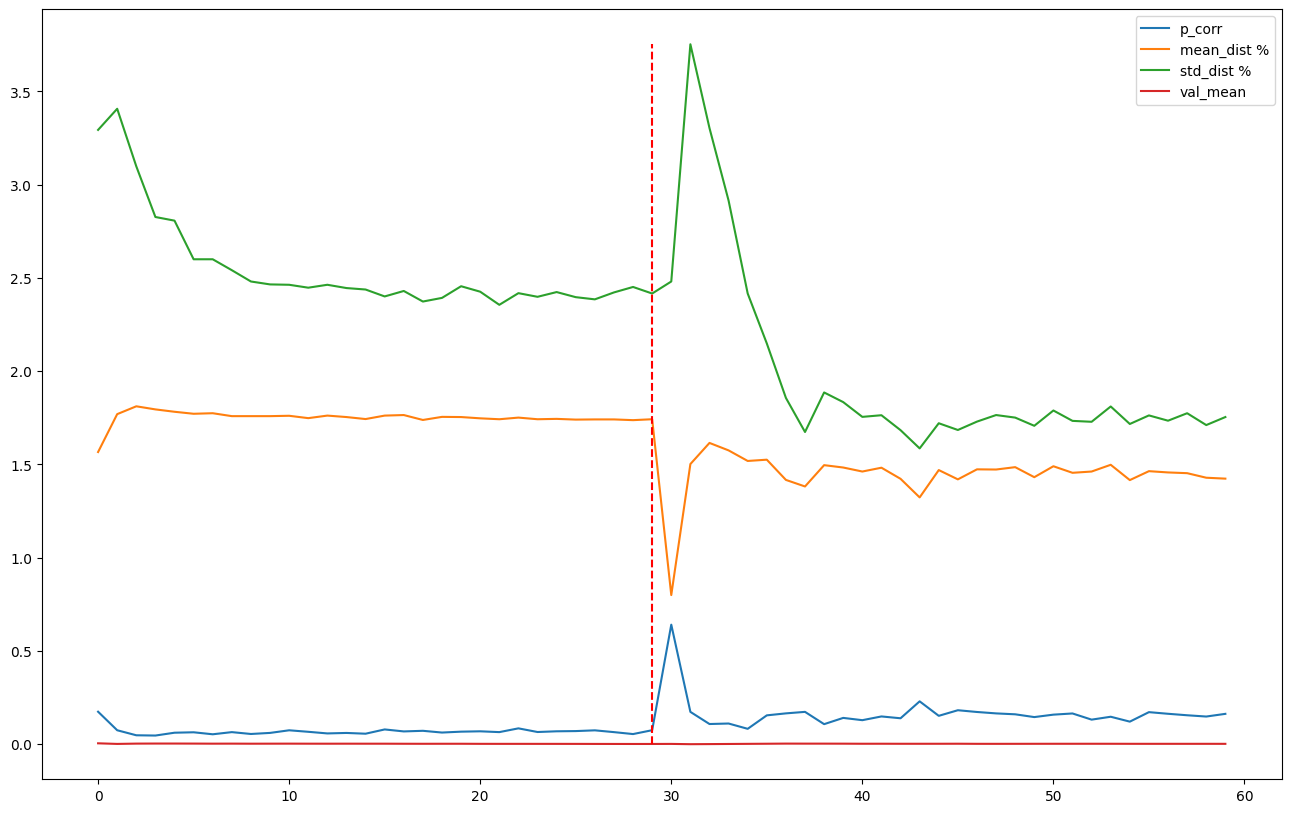

In [47]:
plt.figure(figsize=(16, 10))
k=layer_names[0]
plt.plot(correlation_per_layer[k], label=['p_corr', 'mean_dist %', 'std_dist %', 'val_mean'])
plt.vlines(len(correlation_per_layer[k])//2-1, 0,
    np.max(correlation_per_layer[k]), colors='r',
    linestyles='dashed')
plt.legend()

In [3]:
sample_steps = np.array(np.meshgrid(
    range(6), range(17))).T.reshape(-1, 2)

# indexing: {layer_name}, sample_id, worker_id, element_id
sample_dict = load_grad_files(sample_steps, layer_names, [
    f"exp_data/gradients_resnet/gradients_resnet_t{i}/" for i in range(6)], 0, 2)

sample_dict = {k: np.array(sample_dict[k]).transpose(2, 1, 0) for k in layer_names}

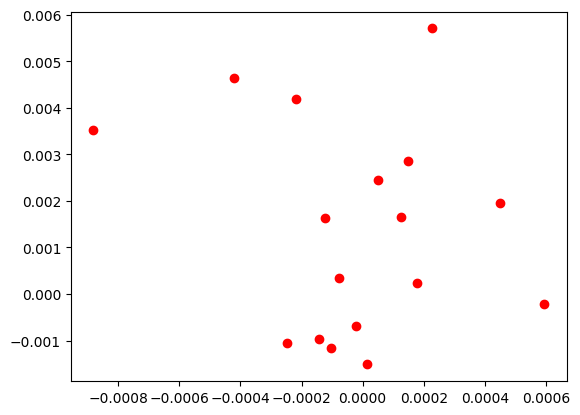

In [55]:
k_id = 9
temp=sample_dict[layer_names[3*k_id]][:,:,:]
element_id = np.argmax(np.mean(np.mean(temp, axis=2), axis=1))
plt.scatter(temp[element_id,0], temp[element_id,1], c='r')
plt.show()

In [45]:
np.mean(temp, axis=2).shape

(147456, 2)